# Random walks on graphs


<div class="note"><span class="note-t">In brief</span>
<p>We turn an eight-node random walk into one <code>PSWAP</code> layer per graph sweep, then carry the same construction over to oriented edges with a directed <code>PJUMP</code> cycle. Refining the layer count separates two errors with different causes: the deterministic bias that comes from chopping simultaneous edge updates into an ordered sequence (<a href="#ref-trotter-1959">Trotter</a> splitting), and the random scatter left over from estimating occupancies out of a finite number of sampled walks (Monte Carlo noise). Running the edge order forward and then in reverse, a symmetric <a href="#ref-strang-1968">Strang</a> sweep, squares the rate at which that bias falls.</p>
</div>

In this tutorial, we express a random walk on a graph (probability mass moving along its edges) as a **parametrised stochastic circuit**: one graph node is one [**pbit**](01_introduction_to_parametrised_stochastic_circuits.ipynb), each edge is one `PSWAP` gate, and a stack of Trotter layers approximates the graph heat flow.

<details class="tx-disclosure"><summary>Term: pbit</summary><p>A pbit is a random binary 0/1 state. Its mean over repeated runs is an occupancy probability.</p></details>

<details class="tx-disclosure"><summary>Term: Trotter and Strang splitting</summary><p>[Trotter splitting](#ref-trotter-1959) replaces simultaneous evolution by many small ordered edge updates. [Strang splitting](#ref-strang-1968) uses a forward-and-back symmetric edge order to cancel the leading splitting error.</p></details>

The graph Laplacian is a sum of edge terms, so the continuous-time walk splits into small two-node updates. A single `PSWAP` is the exact update for one edge, which means a layer holding one `PSWAP` per edge, repeated in time, approximates the full walk.

We build that up in stages. First we map one edge to one `PSWAP` gate, which implements the exact two-node Markov kernel (the transition rule for one step of the walk). Then we compose an eight-node graph as one Trotter layer of `PSWAP` gates and watch the distribution diffuse. Finally we sweep the Trotter resolution, because that sweep is what pulls Trotter bias apart from Monte Carlo noise, square the convergence rate with a symmetric Strang sweep, and carry the construction over to directed edges with the `PJUMP` gate.

We assume familiarity with the gate set from [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb), and the code uses Torx, JAX, NumPy, and NetworkX.


## Setup

The setup cells put the shared `helpers` directory on the import path.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>Torx builds and samples the <code>PSWAP</code> and <code>PJUMP</code> circuits.</li><li>NumPy computes the generator, exact eigensolution, and deterministic product-formula baselines in <code>examples/helpers/_graph_diffusion.py</code> and this notebook.</li><li>JAX and Equinox compile, vectorize, and recombine per-source Torx runs inside <code>examples/helpers/_graph_diffusion.py</code>.</li><li><code>examples/helpers/_plots_sampling.py</code> and <code>examples/helpers/_plots_schematics.py</code> draw the figures.</li></ul></details>

In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import networkx as nx
import numpy as np

from torx.psc import DiscretePCircuit, PSWAP, BranchingSimulator



In [2]:
# Resolve helper imports whether the notebook runs from the root or notebook directory.
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _graph_diffusion import (
    _edge_swap_probability as shared_edge_swap_probability,
    build_graph_generator,
    reference_heat_flow,
    sample_pswap_product_formula,
    sample_pswap_product_formula_multiseed,
)
import _plots_sampling as P_samp
import _plots_schematics as P_sch
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)


In [4]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)

## What the circuit computes

Before writing any gates, we establish why a graph walk becomes a circuit at all. The whole construction rests on one structural fact: the generator of the walk is a sum of one term per edge, and each of those terms has an exact gate.

The walk spreads an occupancy distribution $p(t)$ over time, and it obeys the master equation (the rule for how the distribution changes over time) $\dot p = Qp$.

The exact answer is the matrix exponential $p(t) = e^{tQ}p_0$. For a symmetric graph walk the generator (the matrix that drives the time evolution) is minus the graph Laplacian, $Q = -L$, where

$$
L \;=\; \sum_{\{i,j\} \in E} w_{ij}\,(e_i - e_j)(e_i - e_j)^\top, \qquad L\mathbf 1 = 0
$$

In the code below, every edge uses the same walk rate `RATE`, so $w_{ij} = \texttt{RATE}$ and $w_{ij}\,\Delta t = \texttt{RATE}\,\Delta t$ is the first-order term of the exact `PSWAP` probability.

The Laplacian is a sum of edge-local terms, so the heat flow $\dot p = -Lp$ splits the same way. That per-edge structure gives a circuit layer with one `PSWAP` per edge:

$$
\underbrace{T}_{\vphantom{\big|}\text{Trotter layer}} \;=\; \prod_{\{i,j\} \in E} \mathrm{PSWAP}_{ij}(p_{ij}), \qquad
\mathrm{PSWAP}_{ij}(p_{ij}) = \mathbb I - \underbrace{p_{ij}}_{\vphantom{\big|}\text{swap prob}}\,(e_i - e_j)(e_i - e_j)^\top
$$

The product runs one `PSWAP` per edge, each a two-node walk on edge $\{i,j\}$. Its rank-one term $(e_i - e_j)(e_i - e_j)^\top$ is the same edge-local operator that appears in $L$.

Each `PSWAP` is the *exact* edge propagator $e^{\Delta t\,Q_{ij}}$ on its edge, and the occupancy form $\mathbb I - p_{ij}(e_i-e_j)(e_i-e_j)^\top$ above is the single-walker map it induces. The circuit is the *ordered* product of these edge propagators, repeated $N$ times:

$$
p(t) \;\approx\; \underbrace{\Big(\textstyle\prod_{\{i,j\}\in E} e^{\Delta t\,Q_{ij}}\Big)^{N}}_{\vphantom{\big|}\text{the circuit}} p_0 \;\xrightarrow[N\to\infty]{}\; \underbrace{e^{-Lt}\,p_0}_{\vphantom{\big|}\text{exact heat flow}}, \qquad \Delta t = t/N
$$

The edge generators do not commute, so the ordered product equals $e^{-Lt}$ only in the limit. This is the classical Lie-Trotter product formula ([Trotter 1959](#ref-trotter-1959)). The first-order expansion of one layer is $\mathbb I - \Delta t\,L$ (one Euler step), which is where the $1/N$ Trotter bias studied below comes from.

The schematic below gives that algebra a picture: it follows one highlighted edge from the graph to its `PSWAP` factor, then tiles the per-edge gates into one Trotter layer $T$. How those layers stack in time comes later, in the four-node ring circuit figure.

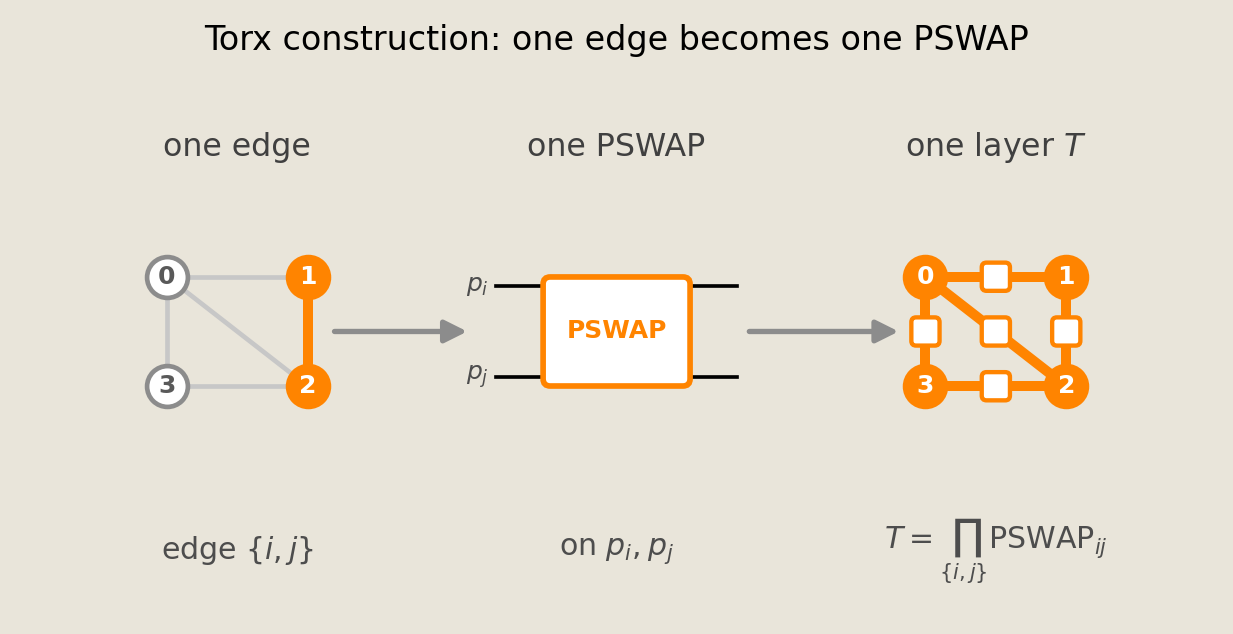

In [5]:
# A tiny toy graph just for the schematic (panel 1); the real 8-node graph
# is built in the "Building the graph" section below. Highlight one edge to carry through the decomposition.
toy_edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
toy_pos = {0: (-0.9, 0.7), 1: (0.9, 0.7), 2: (0.9, -0.7), 3: (-0.9, -0.7)}

fig = P_sch.decomposition_schematic(
    toy_edges=toy_edges,
    toy_pos=toy_pos,
    highlight_edge=(1, 2),
)
savefig(fig, "02_decomposition")

## One edge, one PSWAP gate

We start with the smallest graph there is, two nodes joined by one edge, because the exact answer is available in closed form and the gate has nowhere to hide.

A walker at node 0 stays with probability $1-p$ and moves to node 1 with probability $p$. For a symmetric two-node walk at rate $r$ over a time $\Delta t$:

$$
p \;=\; \tfrac{1}{2}\bigl(1 - e^{-2r\,\Delta t}\bigr).
$$

For the graph examples below, $r$ is the code constant `RATE`, so the first-order term $r\,\Delta t$ is the same $w_{ij}\,\Delta t$ from the Laplacian description.

That $p$ is the swap probability we feed to `PSWAP`, which is parametrised by a logit (the log-odds of the probability) rather than by the probability itself. The wrapper below evaluates it via the shared helper in `examples/helpers/_graph_diffusion.py`, so the sampled circuits and the deterministic baselines later in the notebook all read the same slice probability. For gate-set details, see [`01_introduction_to_parametrised_stochastic_circuits.ipynb`](01_introduction_to_parametrised_stochastic_circuits.ipynb).

In [6]:
def edge_swap_probability(time, rate):
    """Shared symmetric two-node walk probability for one slice."""
    return shared_edge_swap_probability(rate, time, 1)

Turning that formula into a circuit takes three short steps. First we fix a walk rate and an elapsed time, which together define the one-edge transition. Then we wrap a single `PSWAP` gate on two pbits into a circuit, since one edge needs exactly one gate. Finally we draw the circuit, which makes the two-pbit gate explicit on the wires instead of leaving it implied by the code.

In [7]:
RATE = 0.7
DEMO_TIME = 0.8
p_swap = edge_swap_probability(DEMO_TIME, RATE)

In [8]:
# Gates carry only structure (the two pbit sites); the swap logit lives in
# `thetas`, one entry per gate aligned with `circuit.gates`.
edge_circuit = DiscretePCircuit([PSWAP([0, 1])])
edge_thetas = [jnp.array([logit(p_swap)])]

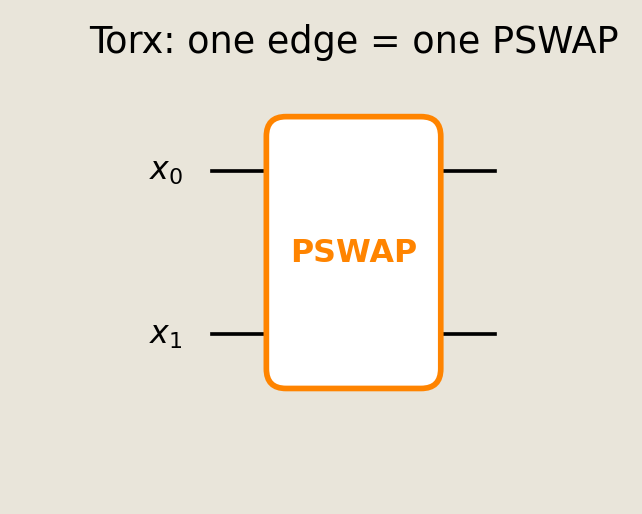

In [9]:
fig = P_sch.draw_pcircuit(
    edge_circuit,
    wire_labels=[r"$x_0$", r"$x_1$"],
    title="Torx: one edge = one PSWAP",
)
savefig(fig, "02_edge_circuit")

With the circuit in place, we check the gate against the formula. We draw 20,000 samples, start the walker on node 0, and read out both endpoint occupancies, because the analytic two-node flow predicts those two numbers exactly.

In [10]:
EDGE_NUM_SAMPLES = 20_000
sim = BranchingSimulator(num_samples=EDGE_NUM_SAMPLES)
compiled = sim.build_circuit(edge_circuit, edge_thetas)

# Start the walker at node 0, then read out the two endpoint occupancies.
initial_bits = jnp.array([1, 0], dtype=jnp.int32)
sampled = np.asarray(sim.expval_all(compiled, initial_bits, jax.random.key(0)))
exact_endpoint = np.array([1.0 - p_swap, p_swap])

print(f"swap probability:           {p_swap:.3f}")
print(f"exact occupancies:          {np.round(exact_endpoint, 3).tolist()}")
print(f"Torx sampled occupancies:   {np.round(sampled, 3).tolist()}")

swap probability:           0.337
exact occupancies:          [0.663, 0.337]
Torx sampled occupancies:   [0.6620000004768372, 0.33799999952316284]


The sampled occupancies reproduce the analytic two-node flow, and the next cell states how close counts as agreement: within six times the binomial standard error $0.5/\sqrt{N}$ at $N = 20{,}000$ samples. That tolerance is the scale of the sampling scatter itself, so passing it means the remaining gap is noise from finite sampling rather than a wrong gate.

In [11]:
edge_sample_sigma = 0.5 / np.sqrt(EDGE_NUM_SAMPLES)
assert np.allclose(sampled, exact_endpoint, atol=6 * edge_sample_sigma)

## Building the graph

We build the edge set from an eight-node cycle plus four chords across the middle.

The chords give the walker shortcuts across the ring, so the heat front spreads faster than it would on the cycle alone.

In [12]:
NUM_NODES = 8

cycle_edges = [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]
chord_edges = [(0, 4), (1, 5), (2, 6), (3, 7)]
edges = cycle_edges + chord_edges

We load most of the initial probability mass onto node 0 and its two ring neighbours, so the walk starts far from equilibrium and the spreading front has somewhere to spread from.

In [13]:
initial = np.zeros(NUM_NODES)
for node, mass in [(0, 0.70), (1, 0.20), (7, 0.10)]:
    initial[node] = mass
initial /= initial.sum()

In [14]:
graph = nx.Graph()
graph.add_nodes_from(range(NUM_NODES))
graph.add_edges_from(edges)

# Fixed circular layout so every figure uses the same geometry.
angles = np.pi / 2 - 2.0 * np.pi * np.arange(NUM_NODES) / NUM_NODES
pos = {n: np.array([np.cos(a), np.sin(a)]) for n, a in enumerate(angles)}

assert graph.number_of_edges() == len(edges)
assert np.isclose(initial.sum(), 1.0)

## Watching the walk diffuse

Before sampling anything, we look at what the circuit will have to reproduce: the exact heat flow $p(t) = e^{tQ}p_0$ with $Q = -L$. The helpers `build_graph_generator` and `reference_heat_flow` assemble $Q$ and evaluate this matrix exponential, so the panels below are ground truth rather than an estimate.

The first snapshot is the initial state, and its peak is far taller than anything that follows. We therefore clip the shared color scale to roughly the 98th percentile of the post-initial snapshots, which keeps the later spread readable while the $t=0$ peak saturates the warm end.

In [15]:
TOTAL_TIME = 1.4
SNAPSHOT_TIMES = np.array([0.0, 0.35, 0.70, 1.05, 1.40])

generator = build_graph_generator(NUM_NODES, edges, rate=RATE)
snapshots = np.stack(
    [reference_heat_flow(initial, generator, float(t)) for t in SNAPSHOT_TIMES]
)

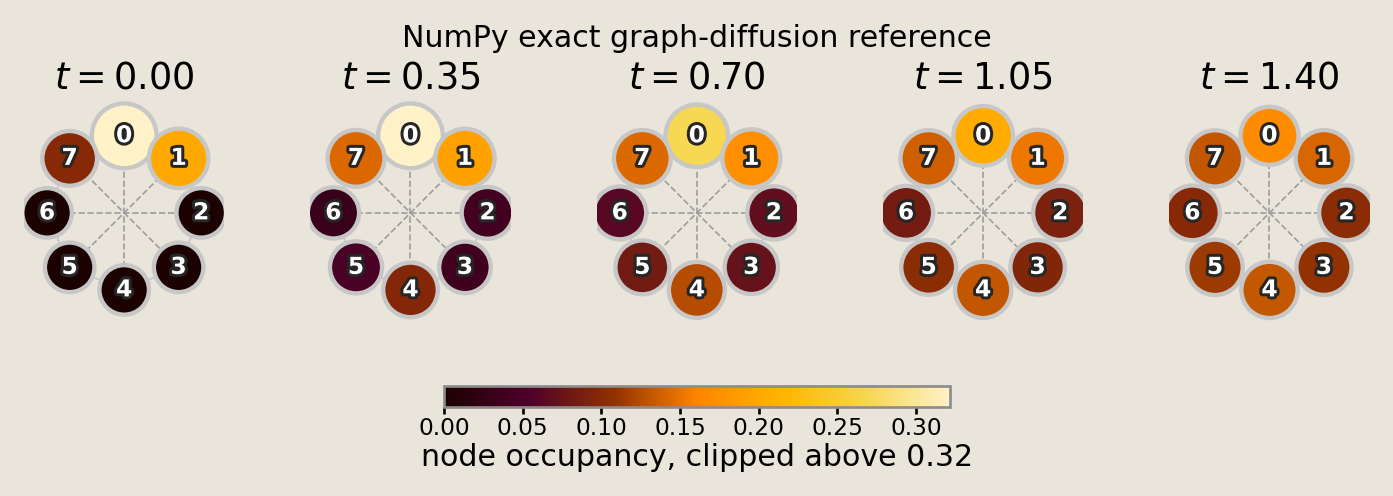

In [16]:
fig = P_sch.diffusion_progression_figure(
    graph,
    pos,
    snapshots,
    SNAPSHOT_TIMES,
    cycle_edges=cycle_edges,
    chord_edges=chord_edges,
)
savefig(fig, "02_diffusion_progression")

Mass leaves the hot nodes 0, 1, and 7 along both the cycle edges and the chord shortcuts, and by the last snapshot it has spread into the rest of the graph as the distribution approaches equilibrium.

## Building the Torx circuit

Now we build the circuit whose job is to approximate that flow. For a Trotter resolution of $m$ steps, each layer applies one `PSWAP` per edge with the swap probability for the slice time $\Delta t = t/m$, and the `DiscretePCircuit` constructor with `reps=m` repeats the whole layer $m$ times.

That repetition is the product $T^m \approx e^{tQ}p_0$ from the heat-flow construction above.

In [17]:
STEPS = 16
dt = TOTAL_TIME / STEPS
p_per_layer = edge_swap_probability(dt, RATE)

In [18]:
pswap_layer = [PSWAP([int(i), int(j)]) for i, j in edges]
layer_thetas = [jnp.array([logit(p_per_layer)]) for _ in edges]
preview = DiscretePCircuit(pswap_layer, reps=STEPS)

print(f"{len(preview.gates)} PSWAP gates per layer  x  {preview.reps} layers")
print(f"swap probability per edge per slice: {p_per_layer:.4f}")

12 PSWAP gates per layer  x  16 layers
swap probability per edge per slice: 0.0576


The eight-node layer carries twelve gates, one per edge, which is more than a diagram can show clearly. A four-node ring uses the same repeated-layer pattern with few enough wires to follow.

In [19]:
ring4 = [(0, 1), (1, 2), (2, 3), (3, 0)]
ring_layer = [PSWAP([int(i), int(j)]) for i, j in ring4]
layer_circuit = DiscretePCircuit(ring_layer, reps=8)

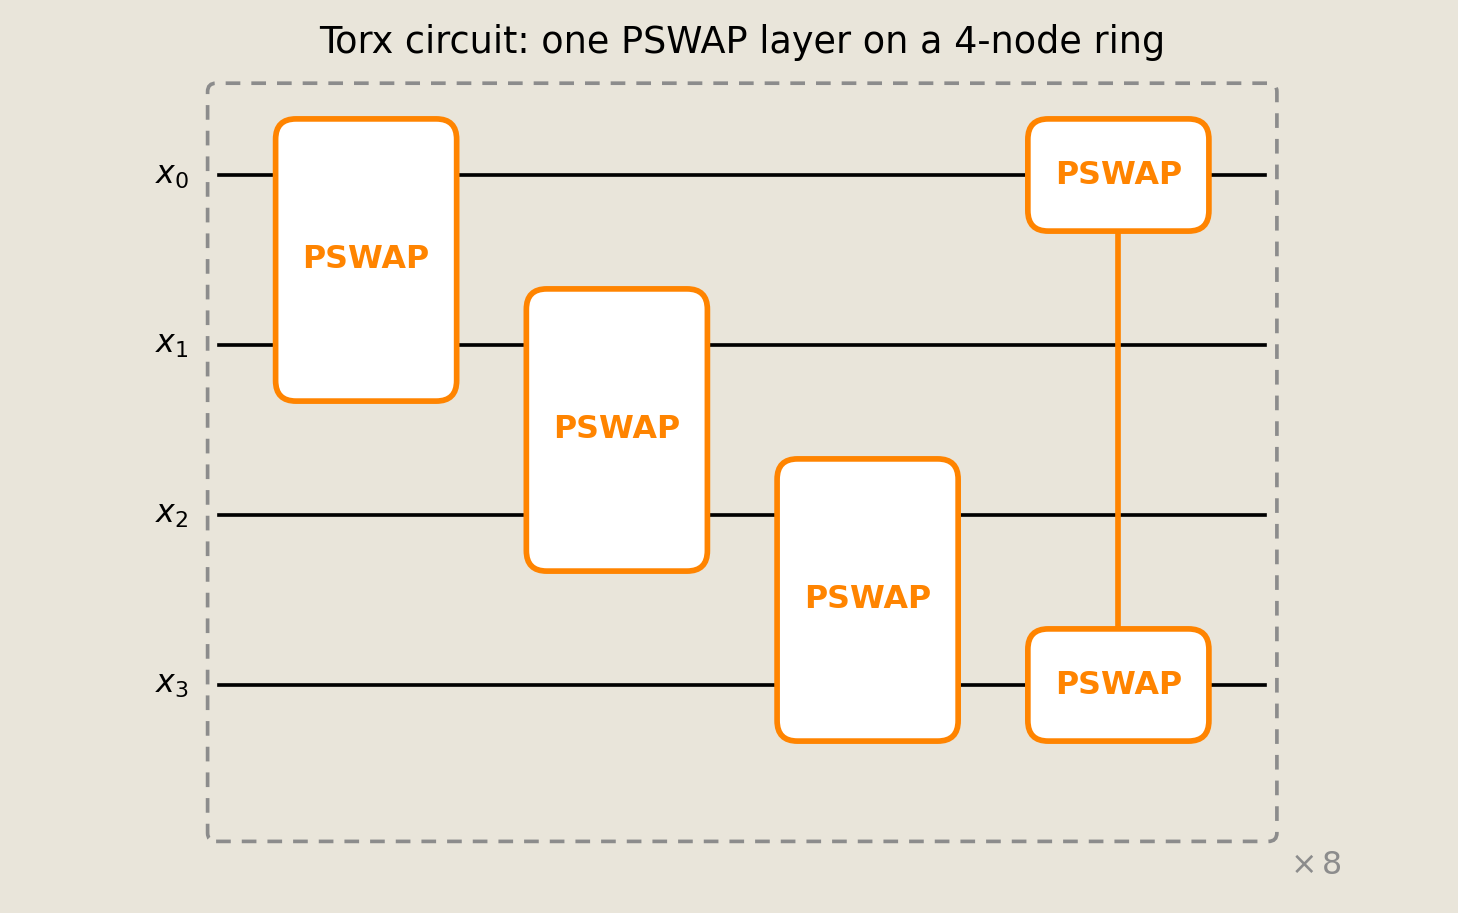

In [20]:
fig = P_sch.draw_pcircuit(
    layer_circuit,
    wire_labels=[rf"$x_{i}$" for i in range(4)],
    title="Torx circuit: one PSWAP layer on a 4-node ring",
    reps=layer_circuit.reps,
)
savefig(fig, "02_layer_circuit")

Sampling reads out where a single walker ends up, so one run cannot represent a start spread across three nodes. The helper `sample_pswap_product_formula` handles that by running the circuit once per occupied source node and recombining the occupancies by the initial weights, which is valid because heat flow is linear in $p_0$.

## Coarse and fine checks

The first question is whether the Trotter resolution matters at all, so we run the same edge layer at a coarse $m=2$ and a finer $m=32$, changing only the resolution: `reps` and the per-slice swap probability that goes with it. The exact $e^{tQ}p_0$ is the reference for both runs, and the printed $L_2$ errors say how far each estimate sits from it.

<details class="tx-disclosure"><summary>Term: L2 error</summary><p>The [$L_2$ norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) is the Euclidean distance across all node occupancies. Zero means the two distributions agree at every node.</p></details>

In [21]:
COARSE_STEPS = 2
FINE_STEPS = 32
NUM_SAMPLES = 12_000

exact = reference_heat_flow(initial, generator, TOTAL_TIME)

In [22]:
def run_circuit(initial, edges, *, steps, total_time, rate, num_samples, seed):
    """Estimate the first-order ordered product formula with the shared sampler."""
    p = edge_swap_probability(total_time / steps, rate)
    return sample_pswap_product_formula(
        initial,
        edges,
        reps=int(steps),
        swap_probability=p,
        num_samples=num_samples,
        seed=seed,
    )

In [23]:
coarse = run_circuit(
    initial,
    edges,
    steps=COARSE_STEPS,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    seed=1,
)
fine = run_circuit(
    initial,
    edges,
    steps=FINE_STEPS,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    seed=2,
)

In [24]:
err_coarse = float(np.linalg.norm(coarse - exact))
err_fine = float(np.linalg.norm(fine - exact))

print(f"coarse (m={COARSE_STEPS:>2}) L2 error: {err_coarse:.3f}")
print(f"fine   (m={FINE_STEPS:>2}) L2 error: {err_fine:.3f}")

coarse (m= 2) L2 error: 0.027
fine   (m=32) L2 error: 0.009


Two things should hold here, and the next cell asserts them separately. Each estimate must still sum to one within twice the binomial standard error, because sampling redistributes probability without creating or destroying it. The finer run must also come out closer to exact than the coarse one at these fixed seeds, which is the first hint that the error at $m=2$ is dominated by the splitting rather than by the sample count.

In [25]:
mass_atol = 2 * 0.5 / np.sqrt(NUM_SAMPLES)
assert np.isclose(coarse.sum(), 1.0, atol=mass_atol)
assert np.isclose(fine.sum(), 1.0, atol=mass_atol)
assert err_fine < err_coarse

## Trotter convergence

Refining $m$ does not improve a sampled estimate forever, because two error sources contribute to the measured gap and they behave differently as $m$ grows.

- **Trotter bias** is the gap between the product formula and exact $e^{tQ}p_0$. First-order Trotter shrinks it as $1/m$: slope $-1$ on a log-log plot.
- **Monte Carlo noise** is the gap between the sampled estimate and the deterministic Trotter mean. By the central limit theorem its scale is $O(1/\sqrt{N})$ in the sample count. It depends on the terminal probabilities, which vary with $m$, but is roughly flat here once the terminal distribution has stabilized.

The deterministic product formula, computed as an exact matrix product per edge, measures pure bias. The sampled Torx estimate uses 12k trajectories per occupied source, 36k total trajectories per seed, across four seeds. The band is the sample standard deviation of those four seeds, so it is an indicative spread rather than a tight confidence interval.

In [26]:
STEPS_SWEEP = [1, 2, 4, 8, 16, 32, 64]
NUM_SEEDS = 4

The next three cells build that pure-bias baseline in NumPy. Each layer walks the edge list in order and applies the same two-by-two mixing the gate performs, so the result carries the ordering error with no sampling scatter on top of it.

In [27]:
def deterministic_trotter_step(occupancy, edge_list, swap_prob):
    """One deterministic edge-product-formula layer on a probability vector."""
    out = occupancy.copy()
    for i, j in edge_list:
        a, b = out[i], out[j]
        out[i] = (1.0 - swap_prob) * a + swap_prob * b
        out[j] = swap_prob * a + (1.0 - swap_prob) * b
    return out




In [28]:
def deterministic_trotter(p0, edge_list, *, m, total_time, rate):
    """Deterministic m-step product formula, no sampling."""
    swap_prob = edge_swap_probability(total_time / m, rate)
    # the edge update is linear, so it applies straight to p0 (no per-source split)
    p = np.asarray(p0, dtype=float).copy()
    for _ in range(m):
        p = deterministic_trotter_step(p, edge_list, swap_prob)
    return p




In [29]:
def sweep_trotter_errors(
    initial,
    edges,
    exact,
    *,
    steps,
    total_time,
    rate,
    num_samples,
    num_seeds,
):
    """Return deterministic and per-seed sampled Trotter errors for each resolution in `steps`."""
    det_errors = np.zeros(len(steps))
    for i, m in enumerate(steps):
        det = deterministic_trotter(
            initial, edges, m=m, total_time=total_time, rate=rate
        )
        det_errors[i] = float(np.linalg.norm(det - exact))

    sampled_errors = np.zeros((len(steps), num_seeds))
    for i, m in enumerate(steps):
        # compile once per resolution, then draw all seeds through it
        p = edge_swap_probability(total_time / m, rate)
        approx_per_seed = sample_pswap_product_formula_multiseed(
            initial,
            edges,
            reps=int(m),
            swap_probability=p,
            num_samples=num_samples,
            seeds=[100 + 7 * m + k for k in range(num_seeds)],
        )
        sampled_errors[i] = np.linalg.norm(approx_per_seed - exact, axis=1)
    return det_errors, sampled_errors

In [30]:
det_errors, sampled_errors = sweep_trotter_errors(
    initial,
    edges,
    exact,
    steps=STEPS_SWEEP,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    num_seeds=NUM_SEEDS,
)

In [31]:
steps_arr = np.asarray(STEPS_SWEEP)
sam_mean = sampled_errors.mean(axis=1)
sam_std = sampled_errors.std(axis=1, ddof=1)

Three claims follow from that two-error picture, and the next cell asserts each one on its own. The deterministic error has to fall at every refinement, because a larger $m$ means a shorter slice and the ordering error is all that is left to shrink. At the coarsest resolution $m=1$ the sampled error has to match the deterministic one within four binomial standard errors, because bias dominates so heavily there that the sampling scatter is invisible beside it. At the finest resolution $m=64$ the sampled error has to sit strictly above the deterministic one, which is the Monte Carlo noise floor described above showing up in the numbers: the bias has fallen below the scatter of a 12,000-sample estimate, so refining further no longer buys the sampled curve anything.

In [32]:
# Pure Trotter bias drops monotonically; the sampled curve plateaus at the MC floor.
mc_match_atol = 4 * 0.5 / np.sqrt(NUM_SAMPLES)
assert np.all(np.diff(det_errors) < 0)
assert abs(sam_mean[0] - det_errors[0]) < mc_match_atol
assert sam_mean[-1] > det_errors[-1]

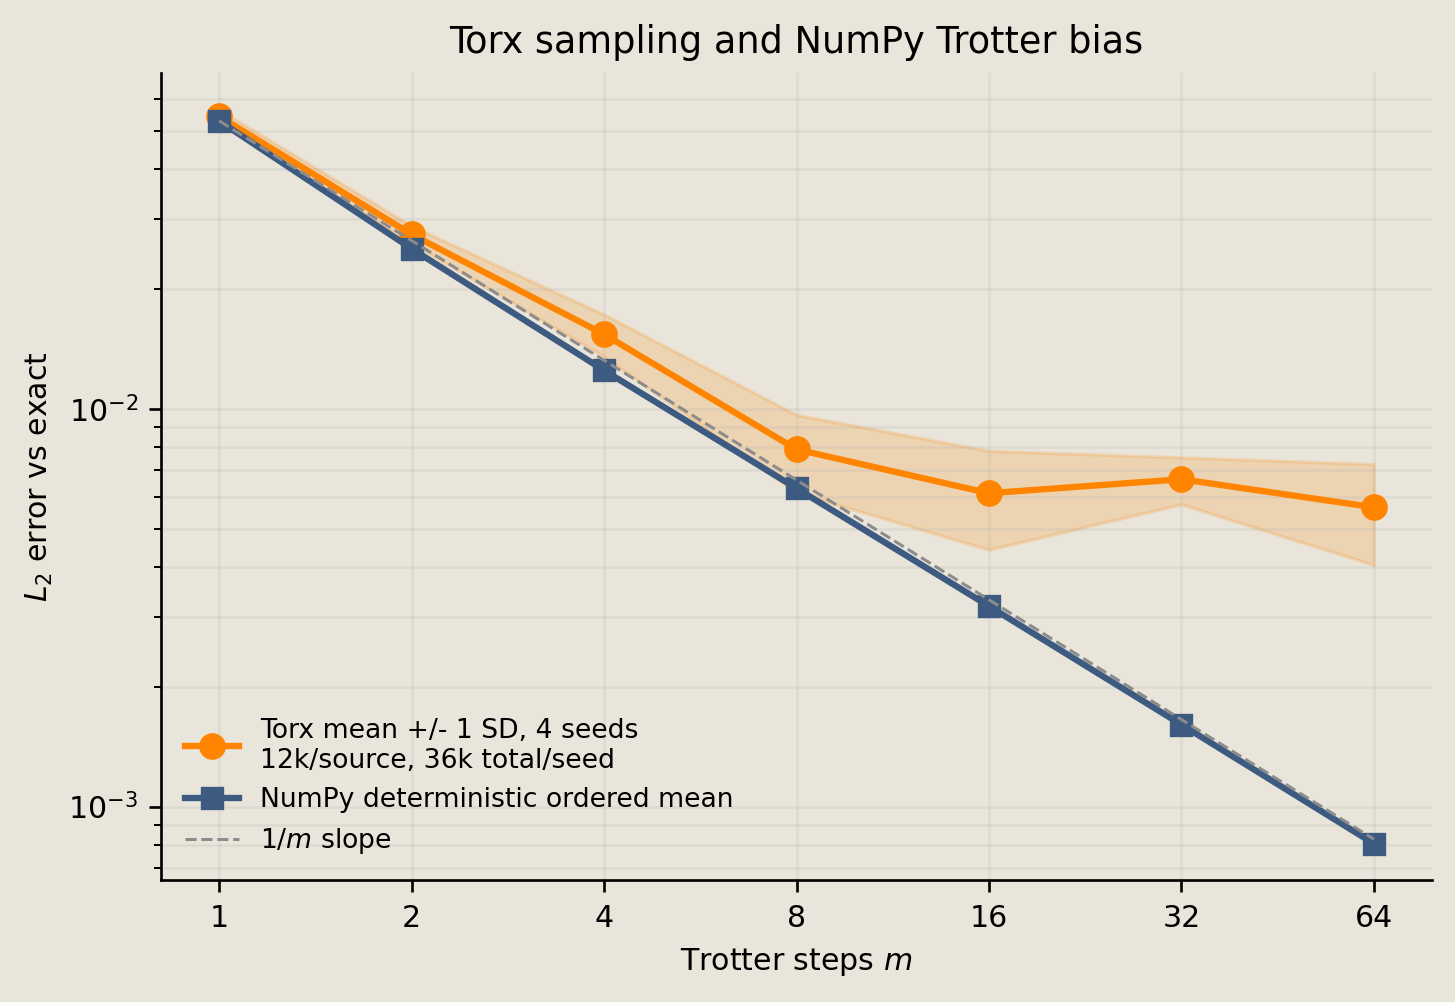

In [33]:
fig = P_samp.trotter_error_figure(
    steps_arr,
    det_errors,
    sam_mean,
    sam_std,
    num_samples=NUM_SAMPLES,
    num_sources=int(np.count_nonzero(initial)),
    num_seeds=NUM_SEEDS,
)
savefig(fig, "02_trotter_error")

At small $m$ the sampled and deterministic curves sit on top of each other, both following the $1/m$ Trotter slope. They separate once the Trotter bias drops below the Monte Carlo floor: the deterministic bias keeps falling as $1/m$, but the sampled error flattens at its $O(1/\sqrt{N})$ noise level.

## Second-order splitting

Each `PSWAP` is the exact edge propagator $e^{Q_{ij}\Delta t}$, so a single edge carries no bias. The $1/m$ error above comes from ordering: the edge generators do not commute, so applying them one after another reproduces $e^{\sum_{ij} Q_{ij}\,\Delta t}$ only to first order in $\Delta t$.

A symmetric sweep removes the leading piece of that error. Run the edges forward for a half step and then in reverse for a half step, and the layer becomes its own mirror image, which cancels the leading $O(\Delta t^2)$ local splitting error from the non-commuting edge updates.

This is the classical **Strang splitting** ([Strang 1968](#ref-strang-1968)), the second-order case of the general higher-order product formulas ([Suzuki 1976](#ref-suzuki-1976)). The cancelled local term leaves a global bias that falls as $1/m^2$.

We write the symmetric layer out in NumPy first, so the order improvement shows up as a clean bias curve with no sampling noise in it. One Strang layer applies the same edge gates forward and then backward, each for half the slice time.

In [34]:
def deterministic_strang_step(occupancy, edge_list, reverse_edges, half_swap):
    """One symmetric layer: a forward edge sweep, then a reverse sweep, each a half step."""
    out = deterministic_trotter_step(occupancy, edge_list, half_swap)
    return deterministic_trotter_step(out, reverse_edges, half_swap)




In [35]:
def deterministic_strang(p0, edge_list, *, m, total_time, rate):
    """Deterministic m-step second-order product formula."""
    half_swap = edge_swap_probability(total_time / m / 2, rate)
    reverse_edges = list(reversed(edge_list))
    # linear update applies straight to p0; reverse list built once, not per step
    p = np.asarray(p0, dtype=float).copy()
    for _ in range(m):
        p = deterministic_strang_step(p, edge_list, reverse_edges, half_swap)
    return p




In [36]:
strang_errors = np.array(
    [
        np.linalg.norm(
            deterministic_strang(initial, edges, m=m, total_time=TOTAL_TIME, rate=RATE)
            - exact
        )
        for m in STEPS_SWEEP
    ]
)

The same scheme runs in Torx, where a Strang layer is the forward edge list followed by its reverse, each gate carrying the half-step probability. We sample it once at the finest resolution $m=32$ to confirm that the circuit and the NumPy baseline describe the same scheme.

In [37]:
def run_strang_circuit(initial, edges, *, steps, total_time, rate, num_samples, seed):
    """Sampled second-order layer: forward edges then reversed, each a half step."""
    half_p = edge_swap_probability(total_time / steps / 2, rate)
    forward_edges = [(int(i), int(j)) for i, j in edges]
    strang_edges = forward_edges + list(reversed(forward_edges))
    return sample_pswap_product_formula(
        initial,
        strang_edges,
        reps=int(steps),
        swap_probability=half_p,
        num_samples=num_samples,
        seed=seed,
    )




In [38]:
strang_sampled = run_strang_circuit(
    initial,
    edges,
    steps=FINE_STEPS,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    seed=7,
)
strang_sampled_err = float(np.linalg.norm(strang_sampled - exact))
print(f"Strang Torx circuit vs exact (m={FINE_STEPS}): L2 = {strang_sampled_err:.4f}")
# the sampled Strang circuit should track exact within the MC floor plus the tiny bias
strang_mc_tol = 6 * 0.5 / np.sqrt(NUM_SAMPLES)
assert strang_sampled_err < strang_errors[-1] + strang_mc_tol

Strang Torx circuit vs exact (m=32): L2 = 0.0059


A slope fit turns the order claim into a number we can check. We regress log error on log $m$ over the five finest resolutions and compare each fitted slope with its expected value, allowing 0.3 of slack: near $-1$ for the first-order product formula, near $-2$ for Strang. The next cell also asserts that Strang is the more accurate of the two at the finest resolution, which is what the steeper slope has to mean once $m$ is large enough.

In [39]:
lie_slope = np.polyfit(np.log(steps_arr[2:]), np.log(det_errors[2:]), 1)[0]
strang_slope = np.polyfit(np.log(steps_arr[2:]), np.log(strang_errors[2:]), 1)[0]
print(f"first-order slope {lie_slope:.2f}   Strang slope {strang_slope:.2f}")

EXPECTED_LIE_SLOPE = -1.0
EXPECTED_STRANG_SLOPE = -2.0
SLOPE_FIT_TOLERANCE = 0.3
assert (
    strang_errors[-1] < det_errors[-1]
), "Strang should be more accurate at the finest resolution"
assert (
    abs(lie_slope - EXPECTED_LIE_SLOPE) < SLOPE_FIT_TOLERANCE
), "first-order bias should fall close to 1/m"
assert (
    abs(strang_slope - EXPECTED_STRANG_SLOPE) < SLOPE_FIT_TOLERANCE
), "Strang bias should fall close to 1/m^2"

first-order slope -0.99   Strang slope -2.00


Putting the two bias curves on one log-log axis turns the order difference into a difference in slope.

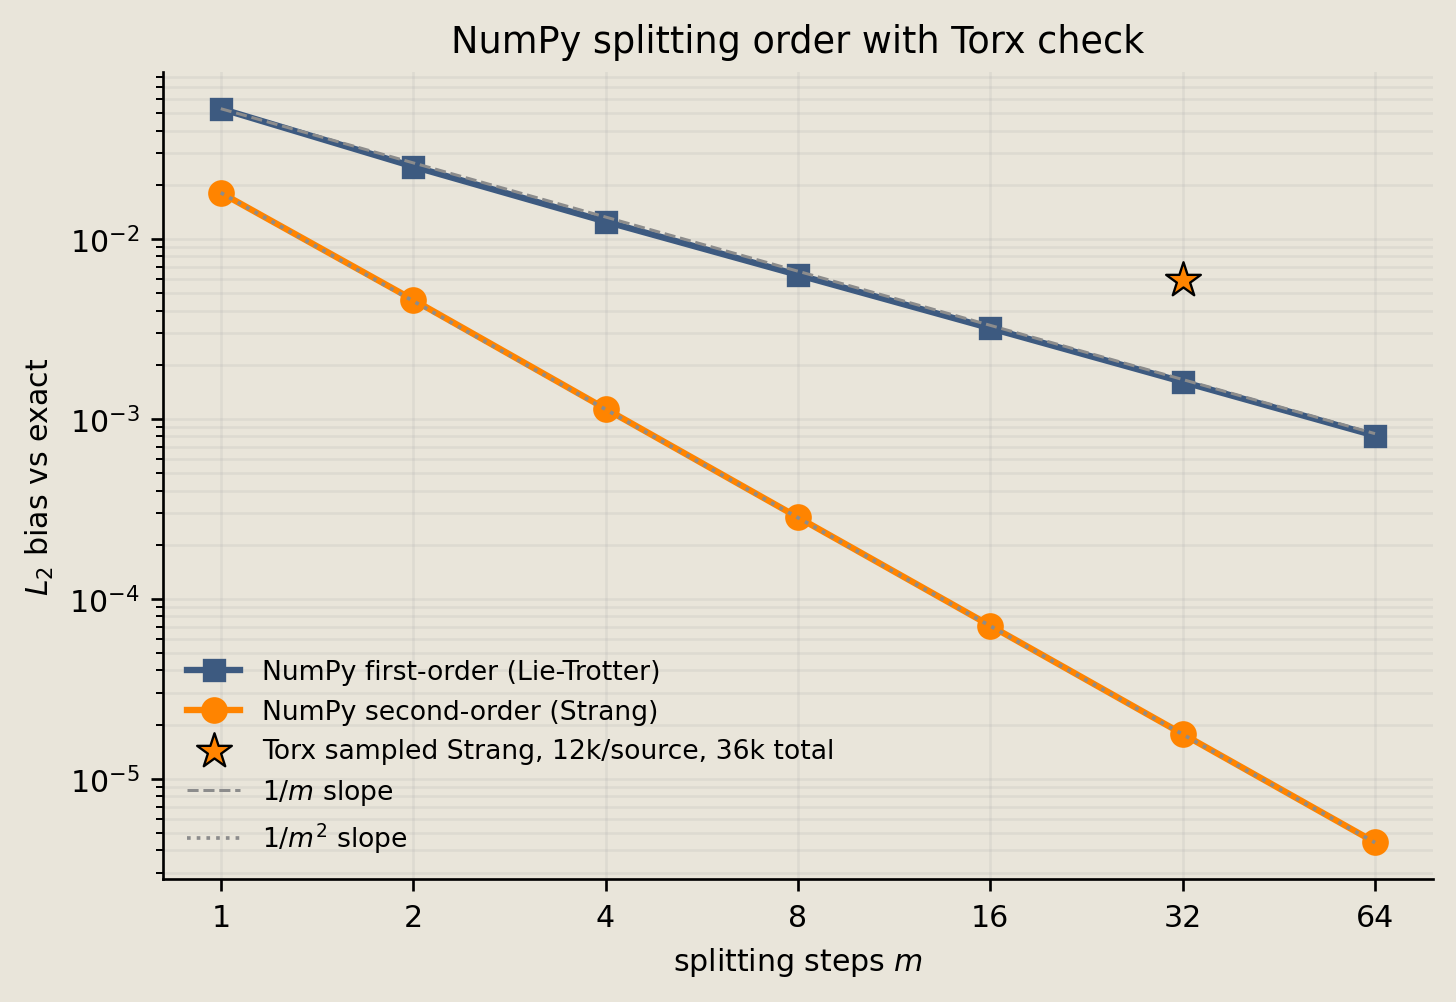

In [40]:
fig = P_samp.splitting_order_figure(
    steps_arr,
    det_errors,
    strang_errors,
    torx_steps=FINE_STEPS,
    torx_error=strang_sampled_err,
    num_samples=NUM_SAMPLES,
    num_sources=int(np.count_nonzero(initial)),
)
savefig(fig, "02_splitting_order")

The two NumPy curves fall at the deterministic $1/m$ and $1/m^2$ bias rates, and the single Torx marker is the sampled Strang result already computed at $m=32$, which is where the sampled circuit can be read against the deterministic second-order curve.

The symmetric Torx circuit costs one extra edge sweep per step. That is a constant factor, so it pays off whenever Trotter bias rather than sample count dominates the target error.

## Directed transport: the PJUMP gate

The `PSWAP` edge above is symmetric: probability flows both ways along an edge. Its directed counterpart is the `PJUMP` gate, which moves a token along an *oriented* edge $a \to b$ at rate $r$. Over a slice $\Delta t$ it sends the token from $a$ to $b$ with probability $p = 1 - e^{-r\,\Delta t}$, but only when $a$ is occupied and $b$ is empty ($a = 1$, $b = 0$). Otherwise it does nothing.

Like `PSWAP`, the gate is parametrised by the logit $\theta = \log\!\big(p / (1 - p)\big)$, and the same Trotter-layer machinery carries over: one `PJUMP` per directed edge is a single layer, and `DiscretePCircuit(gates, reps=m)` repeats it to cover $[0, t]$. The only change from the rest of this tutorial is that the graph is now directed.

In [41]:
from torx.psc import PJUMP

In [42]:
# A short directed cycle: each node has exactly one out-edge, with two rates.
FAST, SLOW = 0.9, 0.4
n_nodes = 5
directed_edges = [
    (0, 1, FAST),
    (1, 2, FAST),
    (2, 3, SLOW),
    (3, 4, FAST),
    (4, 0, SLOW),
]




In [43]:
def pjump_probability(time, rate):
    """Directed-edge jump probability over a slice; the token enters only an empty node."""
    return 1.0 - np.exp(-rate * time)




In [44]:
# Single-particle generator Q: a token at src leaves to dst at the edge rate.
Q = np.zeros((n_nodes, n_nodes))
for src, dst, rate in directed_edges:
    Q[dst, src] += rate
    Q[src, src] -= rate



In [45]:
# One walker starts on node 0.
initial_bits = jnp.zeros(n_nodes, dtype=jnp.int32).at[0].set(1)
p0 = np.zeros(n_nodes)
p0[0] = 1.0
print(f"{n_nodes}-node directed cycle, {len(directed_edges)} directed edges, one walker on node 0")

5-node directed cycle, 5 directed edges, one walker on node 0


The directed gate now gets the same treatment the symmetric one received. We Trotterize with one `PJUMP` per directed edge, sample snapshot circuits at a few rep counts, and compare each sampled occupancy against the exact single-particle reference $e^{Q t} p_0$, which comes from an eigendecomposition of $Q$ rather than from sampling.

In [46]:
def single_particle_occupancy(Q, p0, times):
    """Exact occupancy e^(Q t) p0 for the small real directed generator."""
    vals, vecs = np.linalg.eig(Q)
    coeff = np.linalg.solve(vecs, p0)
    return np.stack([(vecs @ (np.exp(vals * t) * coeff)).real for t in times])




In [47]:
T = 6.0
N = 300
dt = T / N
times = np.linspace(0.0, T, N + 1)
snapshot_reps = np.arange(60, N + 1, 60, dtype=int)
snapshot_times = snapshot_reps * dt

exact_occ = single_particle_occupancy(Q, p0, times)



In [48]:
gates = [PJUMP([int(src), int(dst)]) for src, dst, rate in directed_edges]
thetas = [jnp.array([logit(pjump_probability(dt, rate))]) for src, dst, rate in directed_edges]
sim = BranchingSimulator(num_samples=20_000)
keys = jax.random.split(jax.random.key(0), len(snapshot_reps))
torx_occ = np.stack([
    np.asarray(sim.expval_all(sim.build_circuit(DiscretePCircuit(gates, reps=int(reps)), thetas), initial_bits, key))
    for reps, key in zip(snapshot_reps, keys, strict=True)
])



In [49]:
err = float(np.max(np.abs(torx_occ - exact_occ[snapshot_reps])))
print(f"sampled {len(snapshot_reps)} snapshot circuits at reps {snapshot_reps.tolist()}")
print(f"max |Torx - exact| occupancy: {err:.4f}")
assert err < 0.05
assert np.allclose(torx_occ.sum(axis=1), 1.0, atol=5e-3)

sampled 5 snapshot circuits at reps [60, 120, 180, 240, 300]
max |Torx - exact| occupancy: 0.0074


Across all five snapshots the largest occupancy gap is under 0.05, and every snapshot still sums to one within $5\times10^{-3}$, so the sampled walk tracks the exact directed flow to within sampling scatter. The figure below overlays the two.

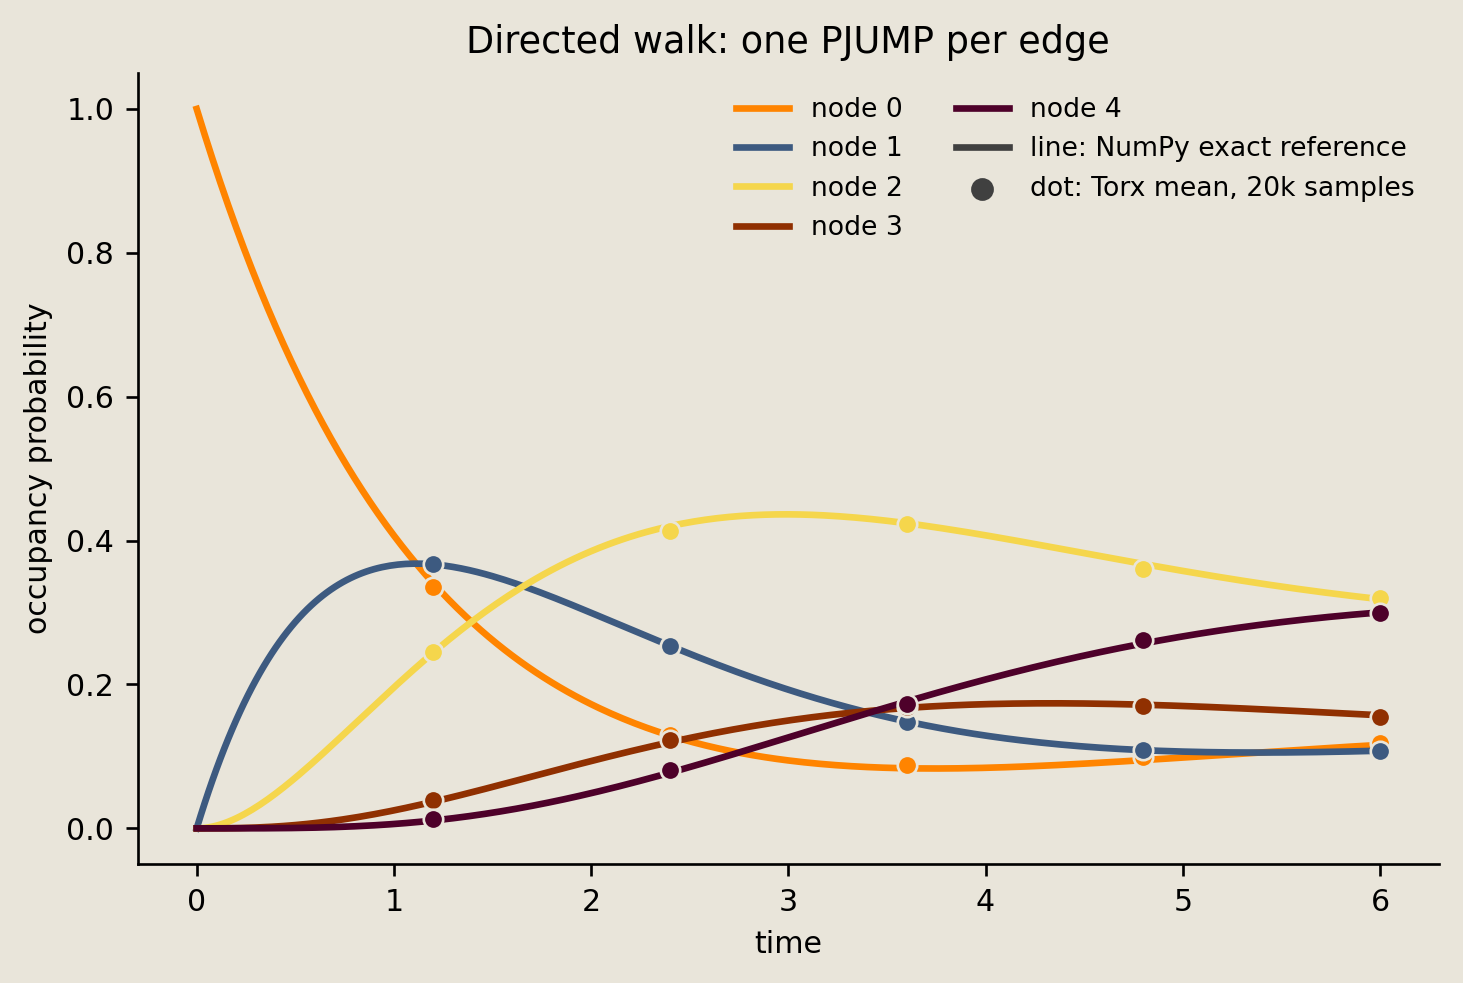

In [50]:
import matplotlib.pyplot as plt
from _notebook_style import FIGURE_BG

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for node in range(n_nodes):
    line, = ax.plot(times, exact_occ[:, node], lw=2.0, label=f"node {node}")
    ax.scatter(
        snapshot_times, torx_occ[:, node], color=line.get_color(),
        s=34, edgecolor=FIGURE_BG, linewidth=0.8, zorder=5,
    )
ax.plot([], [], color="0.25", lw=2.0, label="line: NumPy exact reference")
ax.scatter([], [], color="0.25", s=34, label="dot: Torx mean, 20k samples")
ax.set_xlabel("time")
ax.set_ylabel("occupancy probability")
ax.set_title("Directed walk: one PJUMP per edge")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", frameon=False, ncol=2)
fig.tight_layout()
savefig(fig, "02_directed_transport")

The Torx dots track the NumPy exact lines. With a single walker the destination node is always empty, so the jumps are an ordinary directed random walk. Add more walkers and the empty-target condition becomes binding: a token cannot hop onto an occupied node, so the walkers exclude one another. That turns the graph into an **exclusion process**: the directed, multi-walker analogue of the symmetric walk studied in this tutorial.

## Conclusion

In this tutorial, we represented a continuous-time random walk on a graph as a stack of per-edge `PSWAP` gates, one pbit per node, and checked it against the exact heat flow.

- Each edge becomes one `PSWAP` gate, and the `DiscretePCircuit` constructor with `reps=m` repeats that layer to cover the time interval.
- The `expval_all` method of `BranchingSimulator` reads out node occupancies, recovering the spreading heat front across the eight-node graph.
- Refining the Trotter resolution drives the deterministic product formula toward the exact $e^{tQ}p_0$, with the bias falling as $1/m$.
- Reordering the same edge gates into a symmetric Strang sweep squares the convergence rate, dropping the bias as $1/m^2$.
- The directed `PJUMP` gate reuses the same layer construction on oriented edges, and the sampled walk tracks the exact directed flow $e^{Qt}p_0$.
- The same Laplacian-splits-per-edge pattern carries over to a mesh in [`03_bunny_graph_diffusion.ipynb`](03_bunny_graph_diffusion.ipynb).

## References

1. <span id="ref-strang-1968"></span>Strang, G. 1968. [*On the construction and comparison of difference schemes*](https://doi.org/10.1137/0705041). SIAM J. Numer. Anal. 5(3), 506-517. The symmetric second-order splitting used in the second-order section.
2. <span id="ref-trotter-1959"></span>Trotter, H.F. 1959. [*On the product of semi-groups of operators*](https://doi.org/10.1090/S0002-9939-1959-0108732-6). Proc. Amer. Math. Soc. 10(4), 545-551. The first-order product formula underlying the per-edge Trotter layer.
3. <span id="ref-suzuki-1976"></span>Suzuki, M. 1976. [*Generalized Trotter's formula and systematic approximants of exponential operators…*](https://link.springer.com/article/10.1007/BF01609348). Commun. Math. Phys. 51(2), 183-190. The generalized higher-order product formulas that the symmetric Strang sweep is the second-order case of.
